In [53]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix
from sklearn.naive_bayes import MultinomialNB
from wordcloud import WordCloud

In [17]:
!wget https://lazyprogrammer.me/course_files/spam.csv

--2024-04-11 07:37:12--  https://lazyprogrammer.me/course_files/spam.csv
Resolving lazyprogrammer.me (lazyprogrammer.me)... 104.21.23.210, 172.67.213.166, 2606:4700:3031::6815:17d2, ...
Connecting to lazyprogrammer.me (lazyprogrammer.me)|104.21.23.210|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 503663 (492K) [text/csv]
Saving to: ‘spam.csv.1’

spam.csv.1          100%[===================>] 491.86K  --.-KB/s    in 0.08s   

2024-04-11 07:37:13 (5.73 MB/s) - ‘spam.csv.1’ saved [503663/503663]



In [18]:
df = pd.read_csv('spam.csv', encoding = 'ISO-8859-1')

In [21]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [20]:
df.drop(['Unnamed: 2','Unnamed: 3','Unnamed: 4'], axis =1, inplace = True)

In [22]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [23]:
df.v1.value_counts()

v1
ham     4825
spam     747
Name: count, dtype: int64

In [24]:
df.columns = ['labels','data']

In [25]:
df.head()

,labels,data
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [26]:
df['b_labels'] = df['labels'].map({
    'ham':0,
    'spam':1
})

Y = df['b_labels'].to_numpy()

<Axes: >

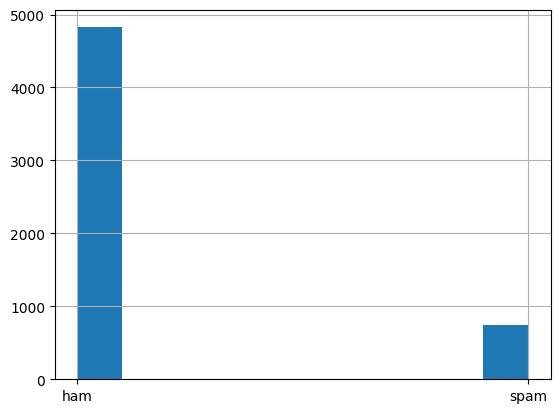

In [27]:
df['labels'].hist()

In [28]:
df_train, df_test, Ytrain, Ytest = train_test_split(
    df['data'], Y , test_size = 0.2, random_state = 42
)

In [29]:
featurizer = CountVectorizer(decode_error = 'ignore')
Xtrain = featurizer.fit_transform(df_train)
Xtest = featurizer.transform(df_test)

In [30]:
Xtrain

<4457x7735 sparse matrix of type '<class 'numpy.int64'>'
	with 58978 stored elements in Compressed Sparse Row format>

In [31]:
Xtest

<1115x7735 sparse matrix of type '<class 'numpy.int64'>'
	with 13941 stored elements in Compressed Sparse Row format>

In [32]:
# Create the model, train it and print scores

model = MultinomialNB()
model.fit(Xtrain, Ytrain)
print("train accuracy:", model.score(Xtrain, Ytrain))
print("Test Accuracy:", model.score(Xtest, Ytest))

train accuracy: 0.9943908458604442
Test Accuracy: 0.9838565022421525


In [34]:
Ptrain = model.predict(Xtrain)
Ptest = model.predict(Xtest)
print("Train F1:", f1_score(Ytrain, Ptrain))
print("Test F1:", f1_score(Ytest, Ptest))

Train F1: 0.9789385004212301
Test F1: 0.9370629370629371


In [35]:
from sklearn.metrics import roc_auc_score

# Assuming Ptrain and Ptest are probabilities or scores from your model

# Calculate ROC AUC score for the train set
roc_auc_train = roc_auc_score(Ytrain, Ptrain)
print("Train ROC AUC:", roc_auc_train)

# Calculate ROC AUC score for the test set
roc_auc_test = roc_auc_score(Ytest, Ptest)
print("Test ROC AUC:", roc_auc_test)


Train ROC AUC: 0.9854338618828165
Test ROC AUC: 0.9456303972366149


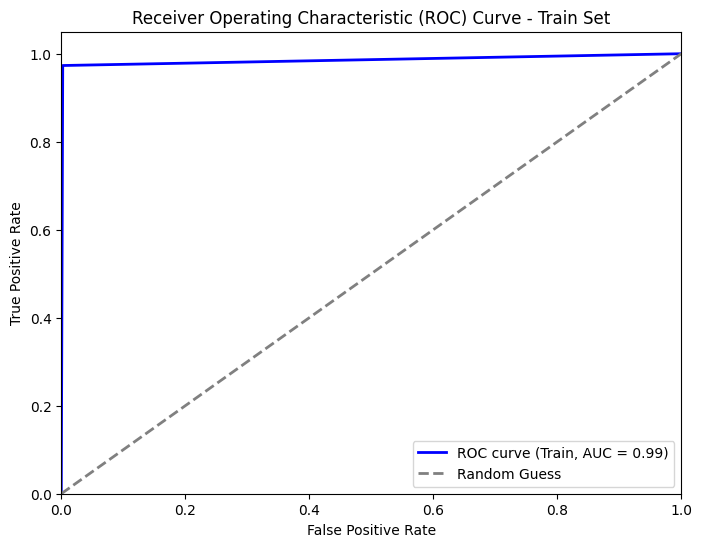

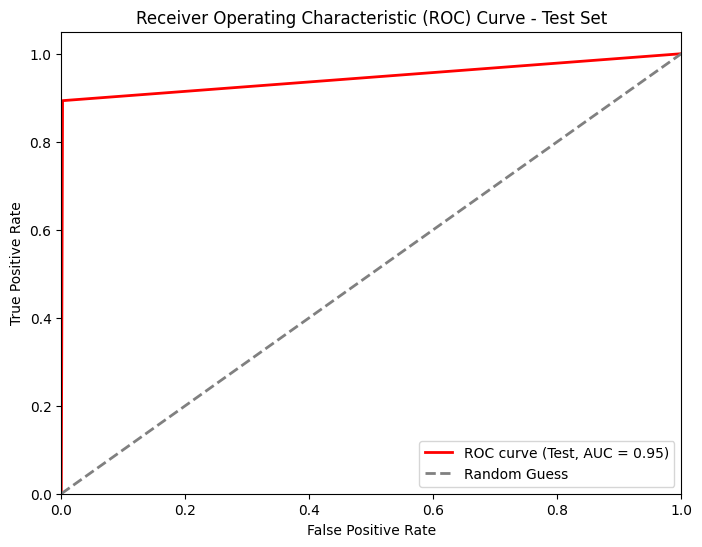

In [57]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Assuming Ptrain and Ptest are probabilities or scores from your model

# Calculate ROC curve for the train set
fpr_train, tpr_train, _ = roc_curve(Ytrain, Ptrain)
roc_auc_train = roc_auc_score(Ytrain, Ptrain)

# Calculate ROC curve for the test set
fpr_test, tpr_test, _ = roc_curve(Ytest, Ptest)
roc_auc_test = roc_auc_score(Ytest, Ptest)

# Plot ROC curve for the train set
plt.figure(figsize=(8, 6))
plt.plot(fpr_train, tpr_train, color='blue', lw=2, label='ROC curve (Train, AUC = %0.2f)' % roc_auc_train)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2, label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Train Set')
plt.legend(loc='lower right')
plt.show()

# Plot ROC curve for the test set
plt.figure(figsize=(8, 6))
plt.plot(fpr_test, tpr_test, color='red', lw=2, label='ROC curve (Test, AUC = %0.2f)' % roc_auc_test)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2, label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Test Set')
plt.legend(loc='lower right')
plt.show()


In [36]:
cm = confusion_matrix(Ytrain, Ptrain)
cm

array([[3851,    9],
       [  16,  581]])

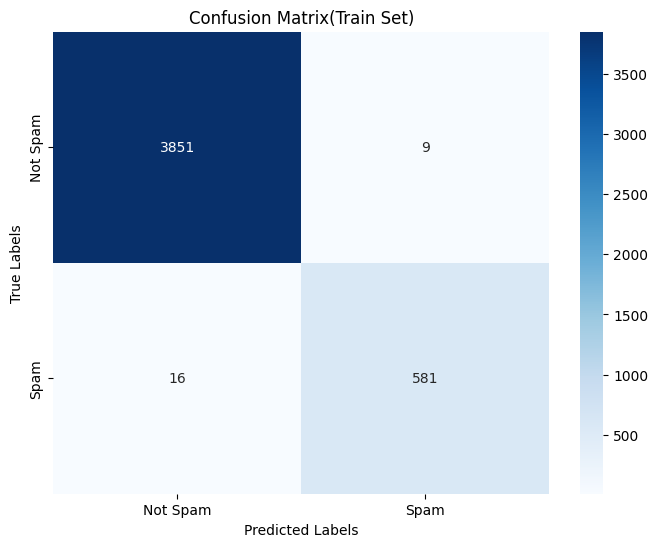

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Assuming cm is the confusion matrix calculated using sklearn confusion_matrix function
# Ytrain is the true labels and Ptrain are the predicted labels or probabilities from your model

# Calculate the confusion matrix
cm = confusion_matrix(Ytrain, Ptrain)

# Define class labels
class_names = ['Not Spam', 'Spam']

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix(Train Set)')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()


In [41]:
cm_test = confusion_matrix(Ytest, Ptest)
cm_test

array([[963,   2],
       [ 16, 134]])

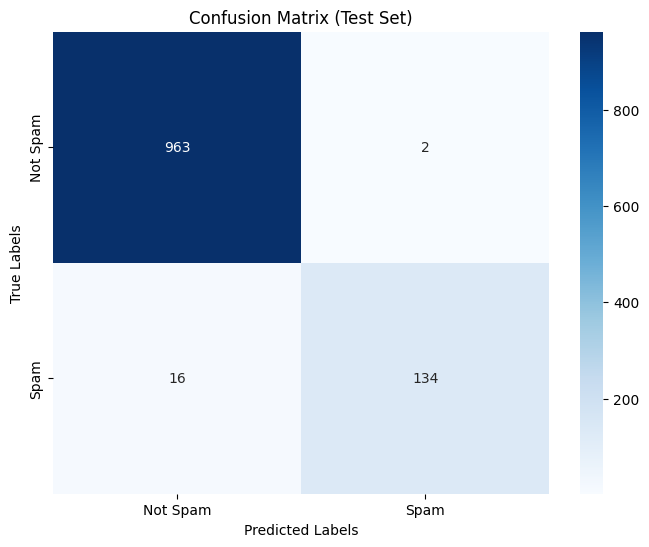

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Assuming cm_test is the confusion matrix calculated using sklearn confusion_matrix function
# Ytest is the true labels and Ptest are the predicted labels or probabilities from your model

# Calculate the confusion matrix for the test set
cm_test = confusion_matrix(Ytest, Ptest)

# Define class labels
class_names = ['Not Spam', 'Spam']

# Plot the confusion matrix for the test set
plt.figure(figsize=(8, 6))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix (Test Set)')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()


In [44]:
def visualize(label):
  words = ''

  for msg in df[df['labels'] == label]['data']:
    msg = msg.lower()
    words += msg + ' '
  wordcloud = WordCloud(width = 600,height = 600).generate(words)
  plt.imshow(wordcloud)
  plt.axis('off')
  plt.show()

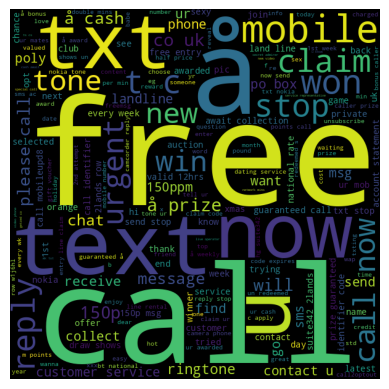

In [45]:
visualize('spam')

In [47]:
# see what we're getting wrong

X= featurizer.transform(df['data'])
df['predictions']  = model.predict(X)

In [48]:
# things that should be spam

sneaky_spam = df[(df['predictions'] == 0) & (df['b_labels'] ==1 )]['data']
for msg in sneaky_spam:
  print(msg)

FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, å£1.50 to rcv
Did you hear about the new \Divorce Barbie\"? It comes with all of Ken's stuff!"
Hi I'm sue. I am 20 years old and work as a lapdancer. I love sex. Text me live - I'm i my bedroom now. text SUE to 89555. By TextOperator G2 1DA 150ppmsg 18+
Email AlertFrom: Jeri StewartSize: 2KBSubject: Low-cost prescripiton drvgsTo listen to email call 123
Do you realize that in about 40 years, we'll have thousands of old ladies running around with tattoos?
Ever thought about living a good life with a perfect partner? Just txt back NAME and AGE to join the mobile community. (100p/SMS)
Hello. We need some posh birds and chaps to user trial prods for champneys. Can i put you down? I need your address and dob asap. Ta r
Can U get 2 phone NOW? I wanna chat 2 set up meet Call me NOW on 09096102316 U can cum here 2moro Luv JANE xx Callså£1/minmoremobsEMSPOBox45P

In [49]:
# # things that should not be spama

# perhaps some are mislabeled

not_actually_spam = df[(df['predictions'] == 1) & (df['b_labels'] ==0 )]['data']
for msg in not_actually_spam:
  print(msg)

Waiting for your call.
Can u get pic msgs to your phone?
We have sent JD for Customer Service cum Accounts Executive to ur mail id, For details contact us
Hey...Great deal...Farm tour 9am to 5pm $95/pax, $50 deposit by 16 May
Unlimited texts. Limited minutes.
Mathews or tait or edwards or anderson
Have you laid your airtel line to rest?
I liked the new mobile
Anytime...
Nokia phone is lovly..
We have sent JD for Customer Service cum Accounts Executive to ur mail id, For details contact us
